In [25]:
#Step - 1 : Downloading Dataset
#Step - 2 : Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Step - 3 : Loading Dataset 

df = pd.read_csv("netflix_titles.csv")
print(df.head())   #First 5 rows
print(df.tail())   #Last 5 rows
print(df.shape)    #No. of rows & columns respectively
print(df.columns)  #Column Names
print(df.dtypes)   #Data types
print(df.describe()) #Basic Stats
print(df.describe(include = "object")) #Gives stats for categorical/text columns


  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [27]:
#Step - 4 : Understanding data

print(df.isnull().sum()) #Missing values in each column
print(df.columns[df.isnull().any()]) #Columns containing missing values
print(df.duplicated().sum()) #No. of duplicate rows

# % of missing values for each column-
print(((df.isnull().sum()/len(df))*100).sort_values(ascending=False))

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
Index(['director', 'cast', 'country', 'date_added', 'rating', 'duration'], dtype='object')
0
director        29.908028
country          9.435676
cast             9.367549
date_added       0.113546
rating           0.045418
duration         0.034064
show_id          0.000000
type             0.000000
title            0.000000
release_year     0.000000
listed_in        0.000000
description      0.000000
dtype: float64


In [28]:
#Step - 5 : Data Cleaning

df.drop_duplicates(inplace=True)
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")
df["date_added"] = pd.to_datetime(df["date_added"], errors = "coerce")

print(df.isnull().sum())
print(df.duplicated().sum())
print(df.info())

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        


C:\Users\raivi\AppData\Local\Temp\ipykernel_2720\1301686252.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df,x = "type",palette=["Red","Blue"])


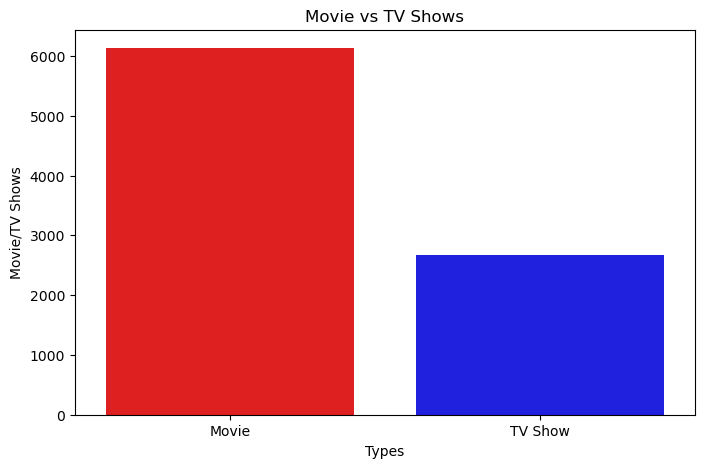

In [29]:
#Step - 6 : Movies vs TV Shows

movie_count = df[df["type"] == "Movie"].shape[0]
tv_count = df[df["type"] == "TV Show"].shape[0]

plt.figure(figsize=(8, 5))
sns.countplot(data = df,x = "type",palette=["Red","Blue"])
plt.title("Movie vs TV Shows")
plt.xlabel("Types")
plt.ylabel("Movie/TV Shows")
plt.show()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
dtype: int64


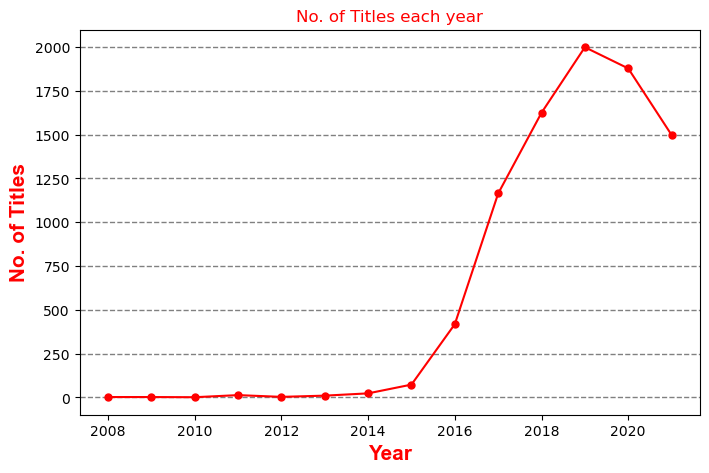

In [30]:
#Step - 7 : Content added over years

df["year_added"] = df["date_added"].dt.year
yearcnt = df.groupby("year_added").size()
print(yearcnt)
plt.figure(figsize=(8,5))
plt.title("No. of Titles each year",color = "Red")
plt.xlabel("Year",fontsize=15,family="Arial",fontweight="bold",color="Red")
plt.ylabel("No. of Titles",fontsize=15,family="Arial",fontweight="bold",color="Red")
plt.grid(axis="y",
         linewidth=1,
         color="grey",
         linestyle="dashed")
plt.plot(yearcnt.index,yearcnt.values,marker="o",markersize=5,color="Red")
plt.show()

rating
66 min         1
74 min         1
84 min         1
G             41
NC-17          3
NR            80
PG           287
PG-13        490
R            799
TV-14       2160
TV-G         220
TV-MA       3207
TV-PG        863
TV-Y         307
TV-Y7        334
TV-Y7-FV       6
UR             3
Unknown        4
dtype: int64


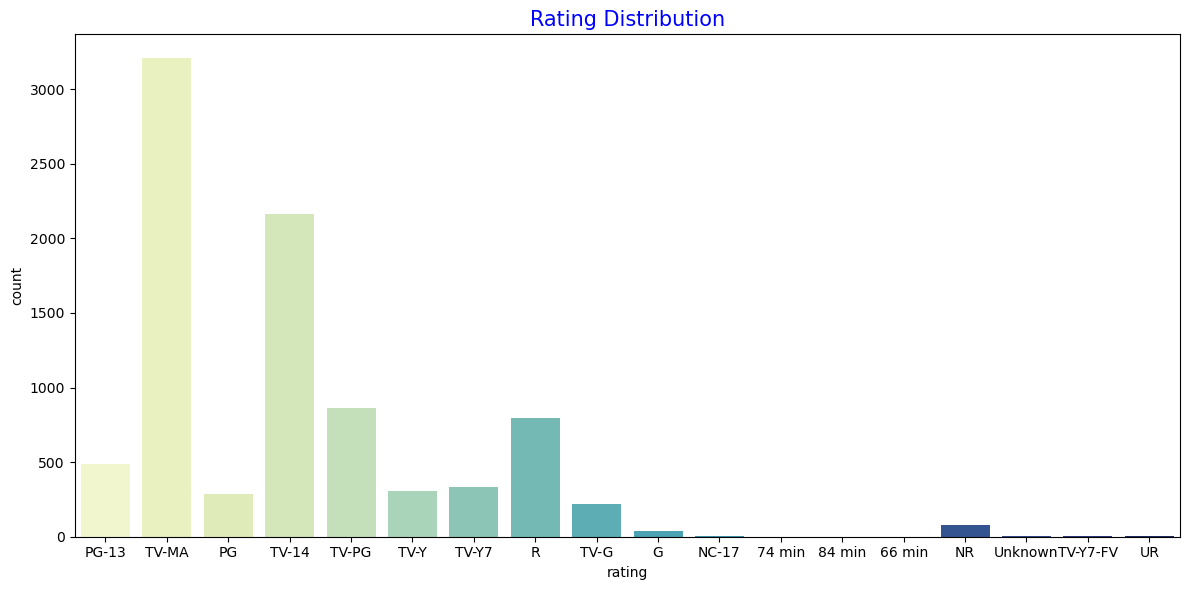

In [31]:
#Step - 8 : Rating Distribution

rating_cnt = df.groupby("rating").size()
plt.figure(figsize=(12,6))
print(rating_cnt)
plt.title("Rating Distribution",color = "Blue",fontsize=15)
sns.countplot(data = df,x = "rating",palette="YlGnBu",hue="rating")
plt.tight_layout()
plt.show()

0        90
6        91
7       125
9       104
12      127
       ... 
8801     96
8802    158
8804     88
8805     88
8806    111
Name: duration_min, Length: 6131, dtype: object
0        90.0
6        91.0
7       125.0
9       104.0
12      127.0
        ...  
8801     96.0
8802    158.0
8804     88.0
8805     88.0
8806    111.0
Name: duration_min, Length: 6131, dtype: float64


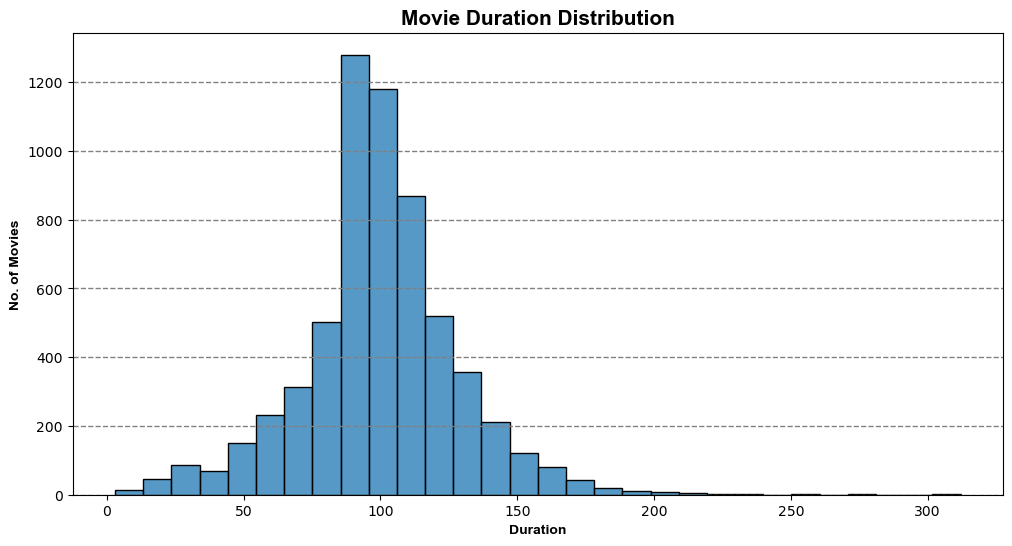

In [32]:
#Step - 9 : Movie Duration Distribution

movies = df[df["type"] == "Movie"].copy()
movies["duration_min"] = movies["duration"].str.split(" ").str[0]
print(movies["duration_min"])  #Still the duration is in the form of an object.
movies["duration_min"] = pd.to_numeric(movies["duration_min"]) #Converting duration from object to numeric.
print(movies["duration_min"])

plt.figure(figsize=(12,6))
plt.title("Movie Duration Distribution", fontsize = 15, family = "Arial", fontweight = "bold")
plt.xlabel("Duration",fontsize=10,fontweight="bold",family="Arial")
plt.ylabel("No. of Movies",fontsize=10,fontweight="bold",family="Arial")
sns.histplot(movies["duration_min"],bins = 30)
plt.grid(axis="y",linewidth=1,color="grey",linestyle="dashed")
plt.show()

0                                      [Documentaries]
1    [International TV Shows, TV Dramas, TV Mysteries]
2    [Crime TV Shows, International TV Shows, TV Ac...
3                             [Docuseries, Reality TV]
4    [International TV Shows, Romantic TV Shows, TV...
5                 [TV Dramas, TV Horror, TV Mysteries]
6                           [Children & Family Movies]
7    [Dramas, Independent Movies, International Mov...
8                       [British TV Shows, Reality TV]
9                                   [Comedies, Dramas]
Name: listed_in, dtype: object
0             Documentaries
1    International TV Shows
1                 TV Dramas
1              TV Mysteries
2            Crime TV Shows
2    International TV Shows
2     TV Action & Adventure
3                Docuseries
3                Reality TV
4    International TV Shows
Name: listed_in, dtype: object
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674

C:\Users\raivi\AppData\Local\Temp\ipykernel_2720\1791623870.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_cnt.head(10).values,y=genre_cnt.head(10).index,palette="YlGnBu")


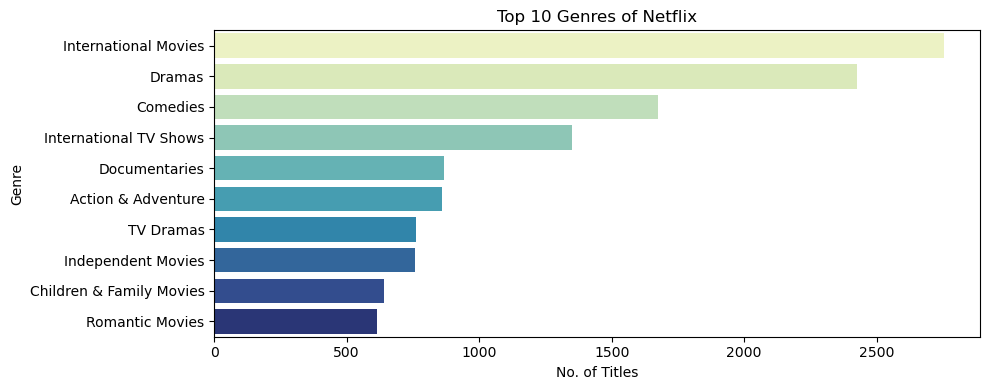

In [33]:
#Step - 10 : Top Genres on Netflix

genre = df["listed_in"].str.split(", ")
print(genre.head(10))
genre = genre.explode()
print(genre.head(10))
genre_cnt = genre.value_counts().sort_values(ascending=False)
print(genre_cnt.head(10))

plt.figure(figsize=(10,4))
sns.barplot(x=genre_cnt.head(10).values,y=genre_cnt.head(10).index,palette="YlGnBu")
plt.title("Top 10 Genres of Netflix")
plt.xlabel("No. of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

year_added  type   
2008.0      Movie         1
            TV Show       1
2009.0      Movie         2
2010.0      Movie         1
2011.0      Movie        13
2012.0      Movie         3
2013.0      Movie         6
            TV Show       4
2014.0      Movie        19
            TV Show       4
2015.0      Movie        56
            TV Show      17
2016.0      Movie       253
            TV Show     165
2017.0      Movie       839
            TV Show     325
2018.0      Movie      1237
            TV Show     388
2019.0      Movie      1424
            TV Show     575
2020.0      Movie      1284
            TV Show     594
2021.0      Movie       993
            TV Show     505
dtype: int64
type         Movie  TV Show
year_added                 
2008.0         1.0      1.0
2009.0         2.0      NaN
2010.0         1.0      NaN
2011.0        13.0      NaN
2012.0         3.0      NaN
2013.0         6.0      4.0
2014.0        19.0      4.0
2015.0        56.0     17.0
2016.0       25

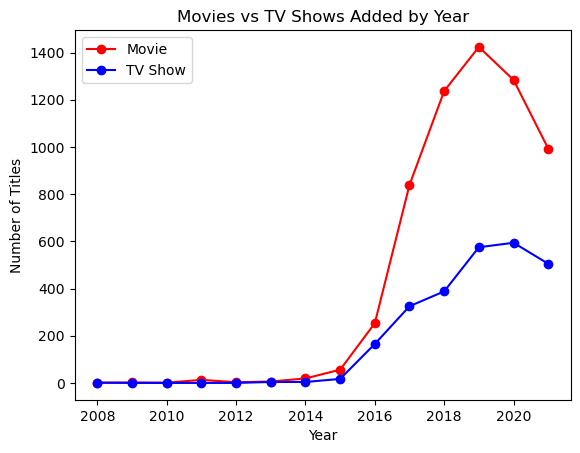

In [34]:
#Step - 11 : Movies vs TV Shows by Year

year_cnt = df.groupby(["year_added","type"]).size()
print(year_cnt)
year_cnt = year_cnt.unstack()
print(year_cnt)
year_cnt = year_cnt.fillna(0)
print(year_cnt)

plt.plot(year_cnt.index,year_cnt["Movie"],label = "Movie",marker="o",markersize=6,color="Red")
plt.plot(year_cnt.index,year_cnt["TV Show"],label = "TV Show",marker="o",markersize=6,color="Blue")
plt.title("Movies vs TV Shows Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.legend()
plt.show()

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
                  ... 
Sudan                1
Jamaica              1
Somalia              1
Kazakhstan           1
Montenegro           1
Name: count, Length: 128, dtype: int64
country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


C:\Users\raivi\AppData\Local\Temp\ipykernel_2720\446482626.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cntry_cnt.head(10).values, y=cntry_cnt.head(10).index, palette="icefire")


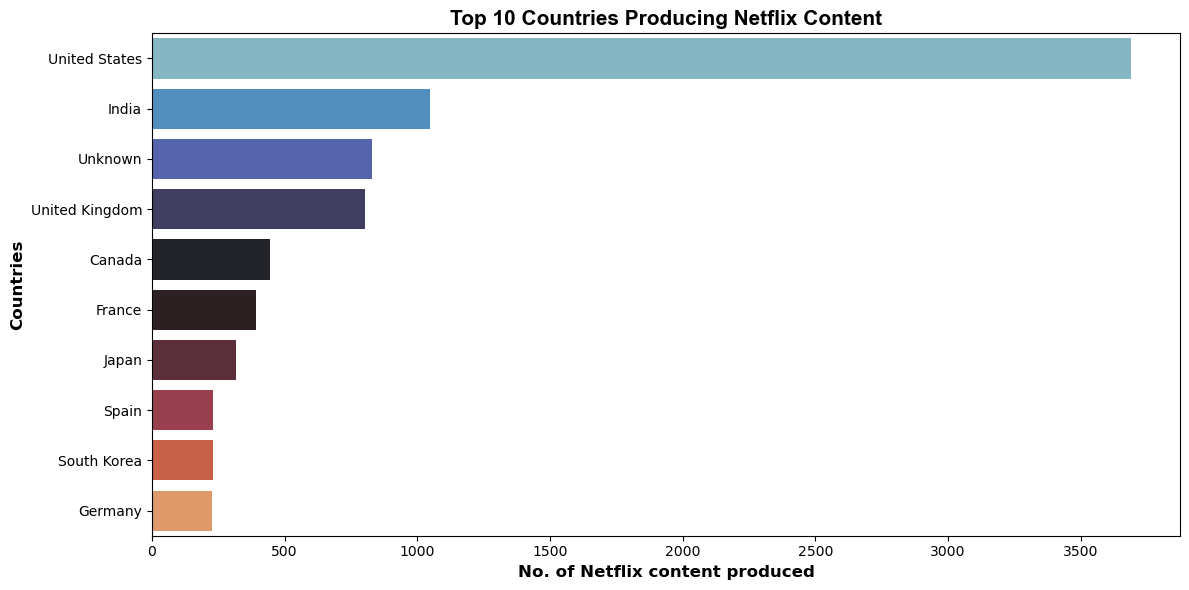

In [35]:
#Step - 12 : Top 10 Countries Producing Netflix Content

cntry = df["country"].str.split(", ")
cntry = cntry.explode()
cntry_cnt = cntry.value_counts().sort_values(ascending = False)
print(cntry_cnt)
print(cntry_cnt.head(10))

plt.figure(figsize=(12,6))
sns.barplot(x=cntry_cnt.head(10).values, y=cntry_cnt.head(10).index, palette="icefire")
plt.title("Top 10 Countries Producing Netflix Content", family = "Arial", fontsize = 15,fontweight = "bold")
plt.xlabel("No. of Netflix content produced",fontsize = 12, fontweight = "bold")
plt.ylabel("Countries",fontsize = 12,fontweight = "bold")
plt.tight_layout()
plt.show()


listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
Documentaries                869
Action & Adventure           859
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
Music & Musicals             375
Horror Movies                357
Stand-Up Comedy              343
Sci-Fi & Fantasy             243
Sports Movies                219
Classic Movies               116
LGBTQ Movies                 102
Anime Features                71
Cult Movies                   71
Faith & Spirituality          65
Movies                        57
Name: count, dtype: int64
listed_in
International TV Shows          1351
TV Dramas                        763
TV Comedies                      581
Crime TV Shows                   470
Kids' TV                         451
Docuseries                       395
Romantic TV Shows                370
Reality TV                       25

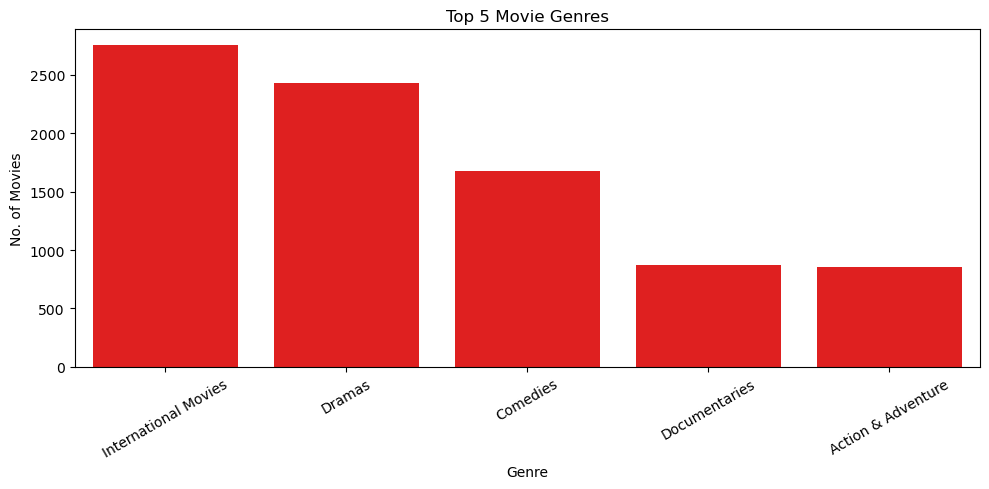

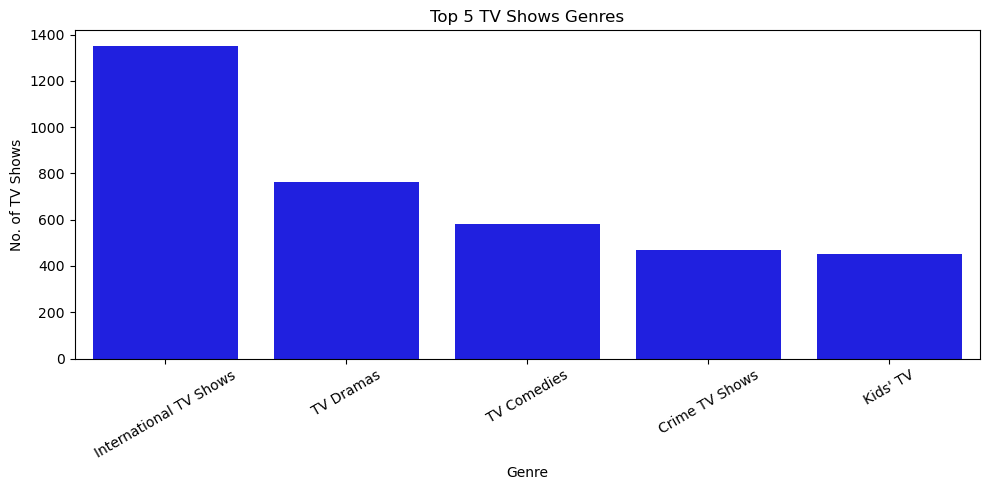

In [36]:
#Step - 13 : Genre Distribution :- Movies vs TV Shows

dfm = df[df["type"] == "Movie"]
dfs = df[df["type"] == "TV Show"]
movie_g = dfm["listed_in"].str.split(", ")
series_g = dfs["listed_in"].str.split(", ")
movie_g = movie_g.explode()
series_g = series_g.explode()

movie_gcnt = movie_g.value_counts()
series_gcnt = series_g.value_counts()
print(movie_gcnt)
print(series_gcnt)
print(movie_gcnt.head(5))
print(series_gcnt.head(5))

plt.figure(figsize=(10,5))
sns.barplot(x=movie_gcnt.head(5).index,y=movie_gcnt.head(5).values,color="Red")
plt.title("Top 5 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("No. of Movies")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(x=series_gcnt.head(5).index,y=series_gcnt.head(5).values,color="blue")
plt.title("Top 5 TV Shows Genres")
plt.xlabel("Genre")
plt.ylabel("No. of TV Shows")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


rating
TV-MA    2062
TV-14    1427
R         797
TV-PG     540
PG-13     490
dtype: int64
rating
TV-MA    1145
TV-14     733
TV-PG     323
TV-Y7     195
TV-Y      176
dtype: int64


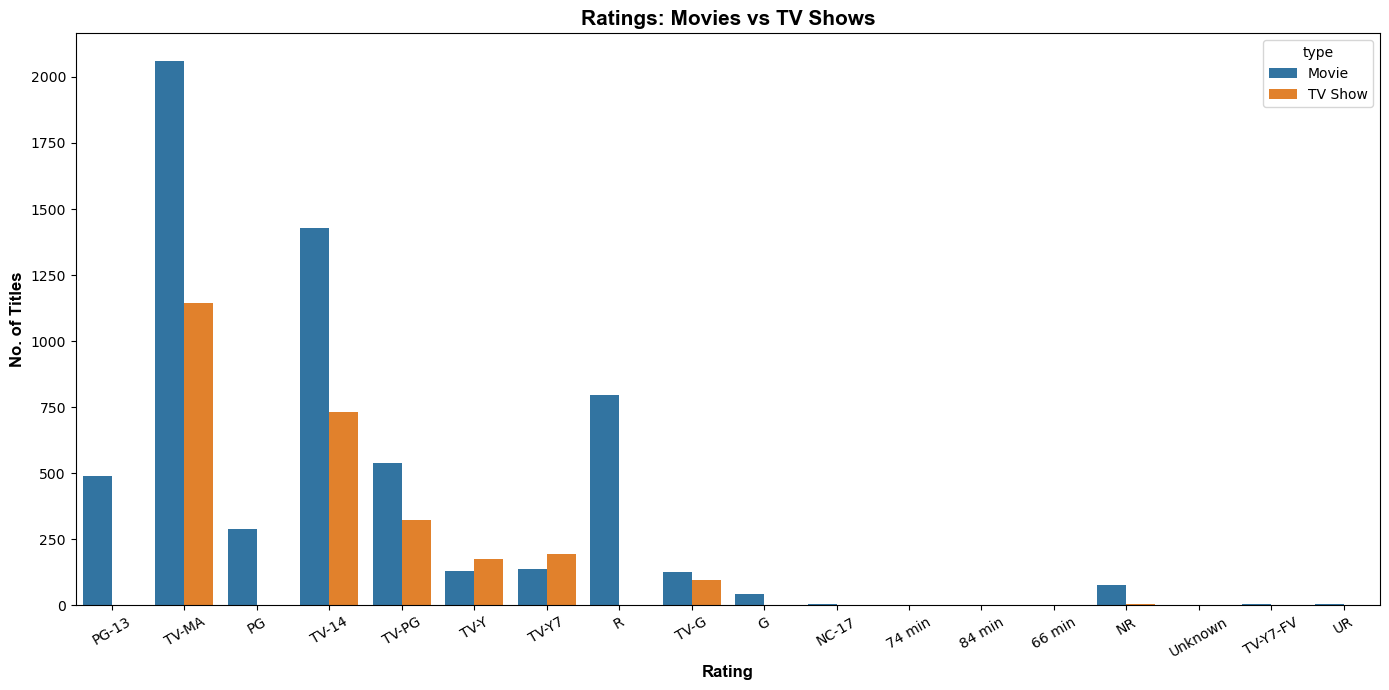

In [37]:
#Step - 14 : Ratings: Movies vs TV Shows

movie_r = dfm.groupby("rating").size().sort_values(ascending=False)
series_r = dfs.groupby("rating").size().sort_values(ascending=False)

print(movie_r.head(5))
print(series_r.head(5))

plt.figure(figsize=(14,7))
sns.countplot(data=df,x="rating",hue="type")
plt.title("Ratings: Movies vs TV Shows",fontsize = 15, fontweight = "bold",family = "Arial")
plt.xlabel("Rating",fontsize = 12, fontweight = "bold",family = "Arial")
plt.ylabel("No. of Titles",fontsize = 12, fontweight = "bold",family = "Arial")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


0        9.0
1        9.0
2        9.0
3        9.0
4        9.0
        ... 
8802    11.0
8803     7.0
8804    11.0
8805     1.0
8806     3.0
Name: date_added, Length: 8807, dtype: float64
date_added
1.0     727
2.0     557
3.0     734
4.0     759
5.0     626
6.0     724
7.0     819
8.0     749
9.0     765
10.0    755
11.0    697
12.0    797
Name: count, dtype: int64
date_added
January      727
February     557
March        734
April        759
May          626
June         724
July         819
August       749
September    765
October      755
November     697
December     797
Name: count, dtype: int64


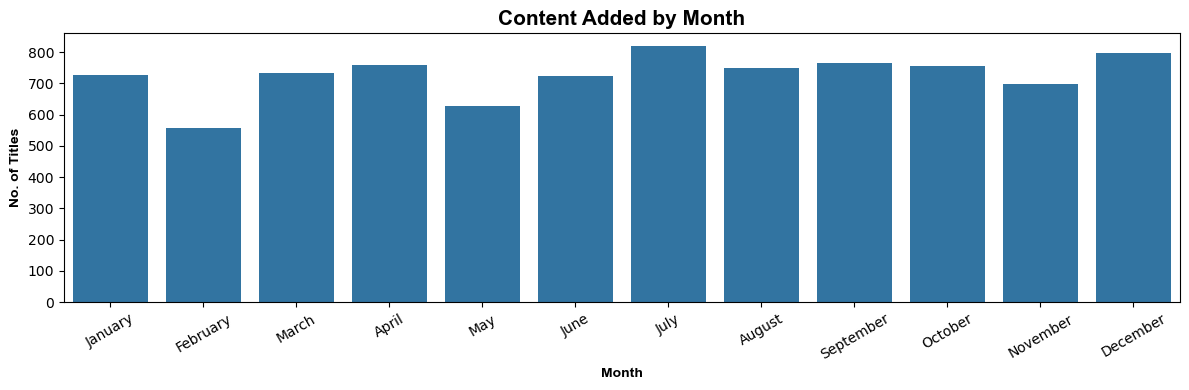

In [38]:
#Step - 15 : Content Added by Month

months = df["date_added"].dt.month
print(months)
month_cnt = months.value_counts().sort_index(ascending=True)
print(month_cnt)
month_cnt.index = pd.to_datetime(month_cnt.index, format="%m").month_name()
print(month_cnt)

plt.figure(figsize=(12,4))
sns.barplot(x=month_cnt.index,y=month_cnt.values)
plt.title("Content Added by Month",family = "Arial",fontweight = "bold",fontsize = 15)
plt.xlabel("Month",family = "Arial",fontweight = "bold",fontsize = 10)
plt.ylabel("No. of Titles",family = "Arial",fontweight = "bold",fontsize = 10)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [39]:
#Step - 16 : Final Netflix EDA Analysis

"""
Key Observations -

1. Netflix has more Movies than TV Shows in the dataset.
2. The number of titles added to Netflix increased significantly over the years, with the highest additions occurring in the later 
   years of the dataset.
3. TV-MA is one of the most common ratings, showing that a large portion of Netflix content is targeted toward mature audiences.
4. Most movies have a duration of approximately 80–120 minutes.
5. International Movies is among the most common genres/categories on Netflix.
6. The United States is the country associated with the largest number of Netflix titles.
7. Movie and TV Show genres have different distributions, with some genres being more popular for movies and others for TV shows.
8. The distribution of ratings also differs between Movies and TV Shows.
9. Netflix adds content throughout the year, with some months having noticeably more additions than others.

Conclusion -

From this EDA, we can see that Netflix's content library is dominated by movies, has a large variety of genres and ratings, and contains 
content from many different countries. The analysis also shows clear differences between Movies and TV Shows in terms of genres, ratings, 
and yearly additions.

This project helped me practice Pandas for data cleaning and analysis, Matplotlib and Seaborn for data visualization, and Exploratory 
Data Analysis (EDA) on a real-world dataset.
"""

"\nKey Observations -\n\n1. Netflix has more Movies than TV Shows in the dataset.\n2. The number of titles added to Netflix increased significantly over the years, with the highest additions occurring in the later \n   years of the dataset.\n3. TV-MA is one of the most common ratings, showing that a large portion of Netflix content is targeted toward mature audiences.\n4. Most movies have a duration of approximately 80–120 minutes.\n5. International Movies is among the most common genres/categories on Netflix.\n6. The United States is the country associated with the largest number of Netflix titles.\n7. Movie and TV Show genres have different distributions, with some genres being more popular for movies and others for TV shows.\n8. The distribution of ratings also differs between Movies and TV Shows.\n9. Netflix adds content throughout the year, with some months having noticeably more additions than others.\n\nConclusion -\n\nFrom this EDA, we can see that Netflix's content library is 